In [26]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
folder_path = './client'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df_client = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)

In [28]:
folder_path = './server'  

csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

df_server = pd.concat((pd.read_csv(file, delimiter=", ", engine="python") for file in csv_files), ignore_index=True)

In [29]:
df = pd.merge(
    df_client,
    df_server,
    on=["Transport Protocol", "Scenario", "Distance (m)"],
    how="inner"  # Only rows that exist in both will be kept
)

In [30]:
df

,Transport Protocol,Scenario,Distance (m),Average RTT (ms),Jitter (ms),Transfer Speed (Mbps),Package Loss (%),Package Size (Bytes),Number of Packages
0,TCP,Inner City,10,38.468485,8.541268,100.895950,0.0,4096,100
1,TCP,Inner City,10,38.468485,8.541268,63.017929,0.0,4096,1000
2,TCP,Inner City,10,38.468485,8.541268,35.567890,0.0,4096,100
3,TCP,Inner City,10,38.468485,8.541268,145.986206,0.0,9216,10000
4,TCP,Inner City,10,38.468485,8.541268,140.180313,0.0,4096,1000
...,...,...,...,...,...,...,...,...,...
3235,TCP,Forest,1,86.340496,9.769584,101.604095,0.0,9216,100
3236,TCP,Forest,1,86.340496,9.769584,109.035118,0.0,9216,10000
3237,TCP,Forest,1,86.340496,9.769584,126.140312,0.0,9216,1000
3238,TCP,Forest,1,86.340496,9.769584,8.730274,0.0,128,1000


In [31]:
df = df[df["Transfer Speed (Mbps)"] < 5000]
df["Distance (m)"] = df["Distance (m)"].replace(30,5)

/var/folders/jr/vldw7_9547930x3qc23wmrr40000gn/T/ipykernel_52413/4271244868.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Distance (m)"] = df["Distance (m)"].replace(30,5)


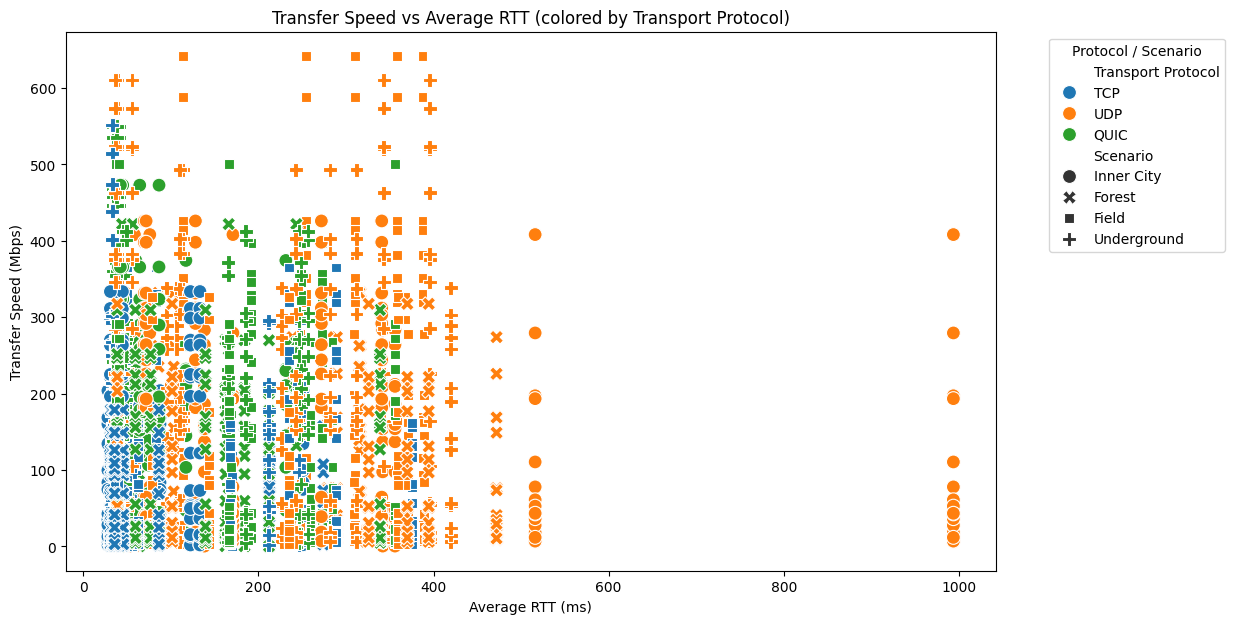

In [32]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Average RTT (ms)', 
    y='Transfer Speed (Mbps)', 
    hue='Transport Protocol', 
    style='Scenario',
    data=df,
    s=100
)
plt.title('Transfer Speed vs Average RTT (colored by Transport Protocol)')
plt.xlabel('Average RTT (ms)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

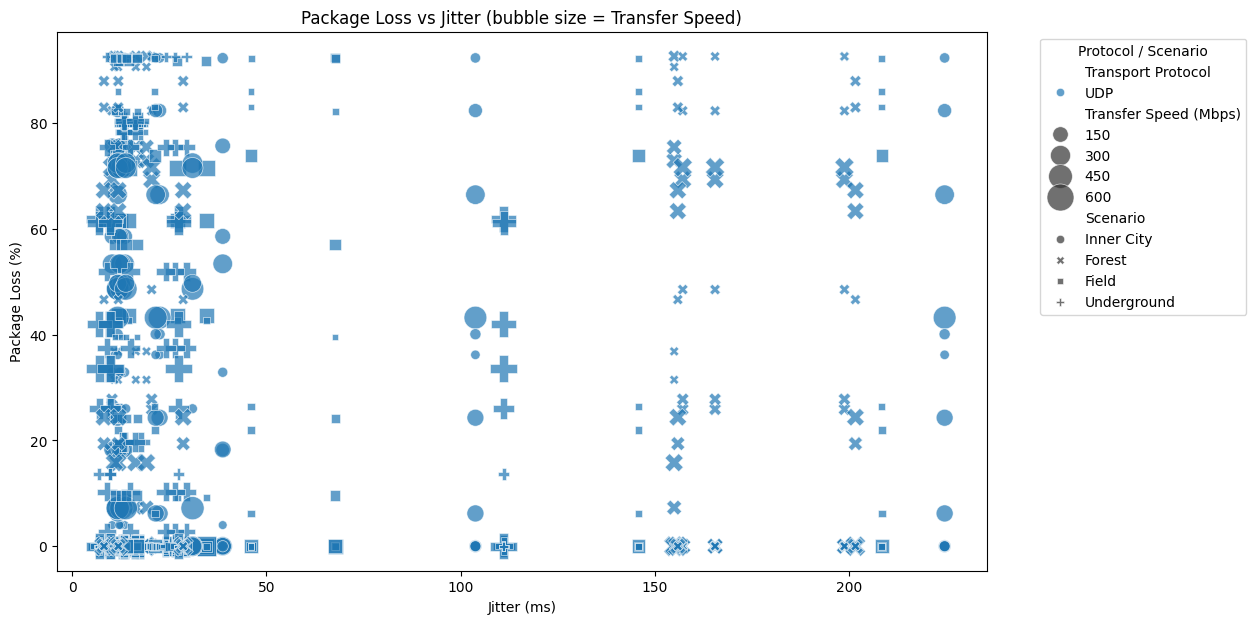

In [33]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Jitter (ms)', 
    y='Package Loss (%)', 
    size='Transfer Speed (Mbps)', 
    hue='Transport Protocol',
    style='Scenario',
    data=df[df["Transport Protocol"] == "UDP"],
    sizes=(40, 400),
    alpha=0.7
)
plt.title('Package Loss vs Jitter (bubble size = Transfer Speed)')
plt.xlabel('Jitter (ms)')
plt.ylabel('Package Loss (%)')
plt.legend(title='Protocol / Scenario', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

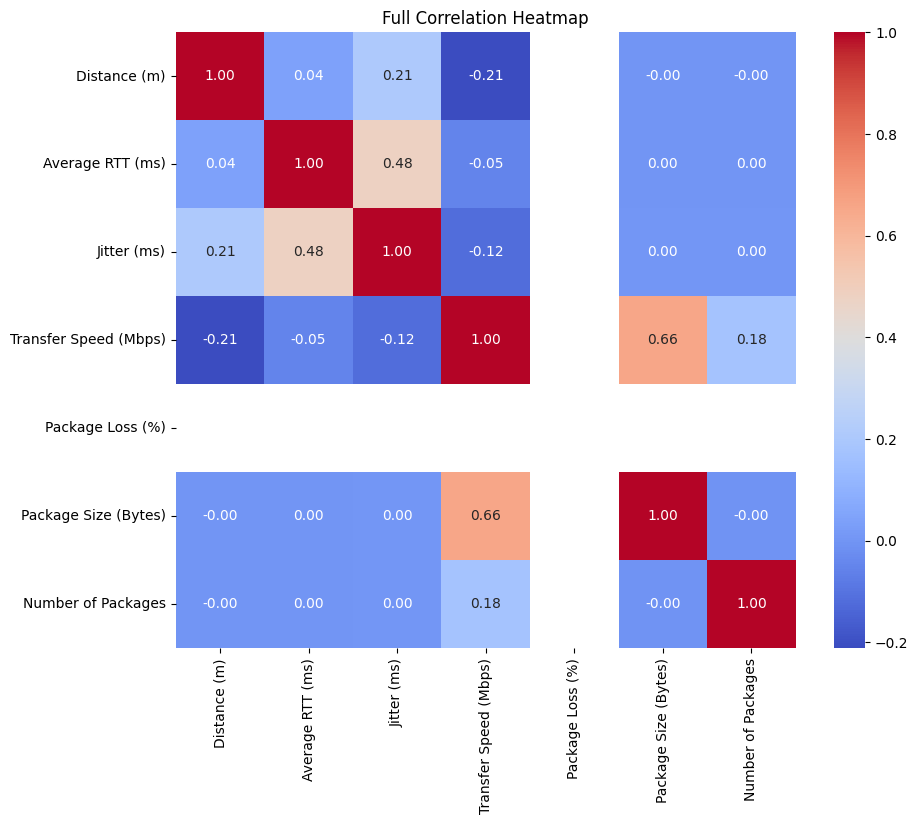

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[df["Transport Protocol"] == "QUIC"].corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Full Correlation Heatmap')
plt.show()

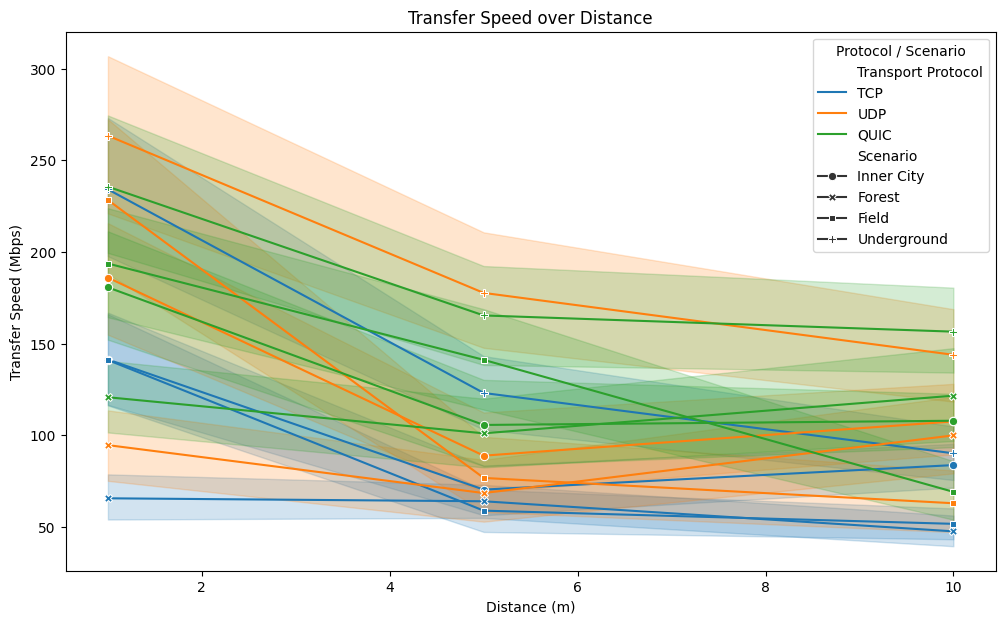

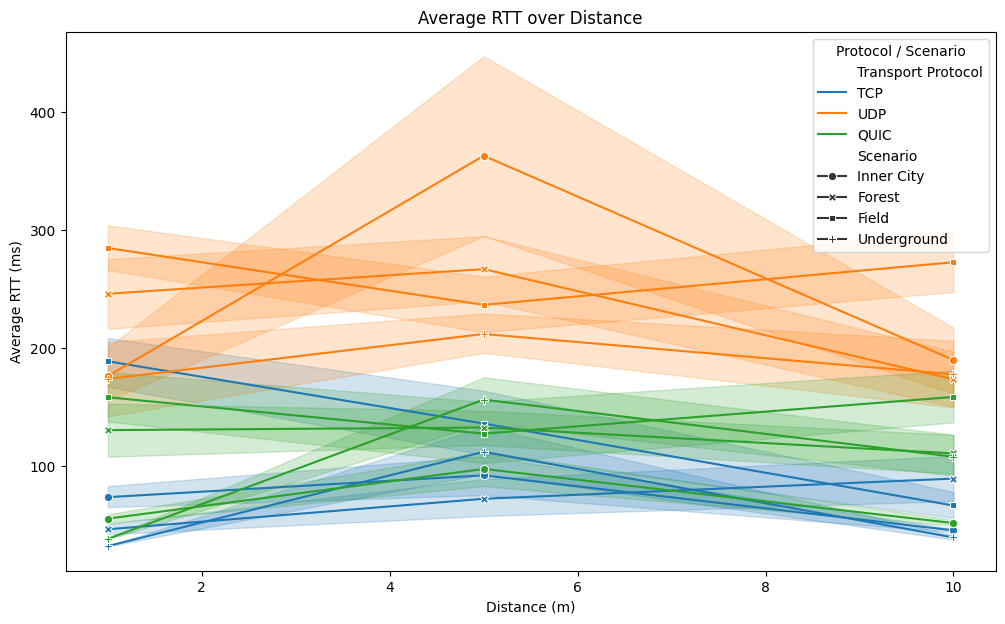

In [35]:
plt.figure(figsize=(12, 7))

# Plot Transfer Speed
sns.lineplot(
    x='Distance (m)', 
    y='Transfer Speed (Mbps)', 
    hue='Transport Protocol', 
    style='Scenario',
    markers=True,
    dashes=False,
    data=df,
    legend='full'
)
plt.title('Transfer Speed over Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Transfer Speed (Mbps)')
plt.legend(title='Protocol / Scenario')
plt.show()

# Plot RTT separately
plt.figure(figsize=(12, 7))
sns.lineplot(
    x='Distance (m)', 
    y='Average RTT (ms)', 
    hue='Transport Protocol', 
    style='Scenario',
    markers=True,
    dashes=False,
    data=df,
    legend='full'
)
plt.title('Average RTT over Distance')
plt.xlabel('Distance (m)')
plt.ylabel('Average RTT (ms)')
plt.legend(title='Protocol / Scenario')
plt.show()